# One electron on three sites — FCI vs free projection vs constrained path

A Hubbard model with an arbitrary (symmetric) hopping matrix and a single electron,

$$
t=\begin{pmatrix}-0.67 & 0.96 & 0.52\\ 0.96 & -0.19 & 0.39\\ 0.52 & 0.39 & 0.03\end{pmatrix},
\qquad U = 10, \qquad n_{\rm elec} = (1,0).
$$

Every AFQMC walker is a single Slater determinant with one occupied orbital, i.e. a real
three-component ray.  On the unit sphere that is two angles,

$$
|\phi\rangle=\sin\theta\cos\varphi\,|100\rangle+\sin\theta\sin\varphi\,|010\rangle+\cos\theta\,|001\rangle ,
$$

the three-site generalisation of the $(\cos\alpha,\sin\alpha)$ walker of
`fp_hubbard_1e2s.ipynb` and of its two-channel product
$(\cos\alpha,\sin\alpha)\otimes(\cos\beta,\sin\beta)$ in `fp_hubbard_2e2s.ipynb`.

**Why $U=10$ still matters.**  One electron never meets a second one, so
$U\,n_\uparrow n_\downarrow$ contributes nothing to the exact Hamiltonian: in this CI basis
$H = h_1$, and FCI $=$ UHF $=$ the lowest eigenvector of $h_1$.  The sampler does not get
that for free.  The Hubbard–Stratonovich transform still puts a fluctuating auxiliary
field on every site, so each walker is kicked around at strength $\sqrt{U\,\delta\tau}$ and
only the *average* over fields collapses back onto the $h_1$ ground state.  Any deviation
below is therefore sampling error or the constrained-path bias — never physics.

## 1.  The model and its mean field

In [1]:
import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from pyscf import fci

import hubbard

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})

NSITE = 3
NELEC = (1, 0)          # one alpha electron
U     = 10.0
T     = np.array([[-0.67,  0.96, 0.52],
                  [ 0.96, -0.19, 0.39],
                  [ 0.52,  0.39, 0.03]])

# `h1=` overrides the nearest-neighbour chain with this explicit hopping matrix.
h1, eri, mol, mf = hubbard.hubbard_mf(NSITE, None, U, NELEC, h1=T, verbose=0)

print("h1 =\n", h1)
print("\none-particle levels :", np.linalg.eigvalsh(h1))
print("E(UHF)             = %+.10f" % mf.e_tot)

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-31-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu
h1 =
 [[-0.67  0.96  0.52]
 [ 0.96 -0.19  0.39]
 [ 0.52  0.39  0.03]]

one-particle levels : [-1.442165 -0.3673    0.979465]
E(UHF)             = -1.4421646329


## 2.  FCI

With one electron the determinant basis is just the three sites, $\{|100\rangle,|010\rangle,|001\rangle\}$,
so FCI is the lowest eigenvector of $h_1$.  We fix the overall sign (a determinant is a ray)
by demanding $c_1>0$.

In [2]:
e_fci, ci = fci.direct_spin1.kernel(h1, eri, NSITE, NELEC)

c_fci = np.asarray(ci).ravel()
c_fci = c_fci * np.sign(c_fci[0])                 # gauge: first component positive
th_fci, ph_fci = hubbard.angles_of(c_fci)

print("E(FCI)          = %+.10f" % e_fci)
print("E(FCI) - E(UHF) = %+.2e   (zero: one electron never sees U)" % (e_fci - mf.e_tot))
print("\nFCI CI coefficients   c = (%+.6f, %+.6f, %+.6f)" % tuple(c_fci))
print("as angles             theta = %+.6f   phi = %+.6f" % (th_fci, ph_fci))

# round trip through the sphere parametrisation
def from_angles(theta, phi):
    "(sin t cos p, sin t sin p, cos t) -- the walker parametrisation of this notebook."
    theta, phi = np.asarray(theta), np.asarray(phi)
    return np.stack([np.sin(theta) * np.cos(phi),
                     np.sin(theta) * np.sin(phi),
                     np.cos(theta)], axis=-1)

print("rebuilt from angles     ", from_angles(th_fci, ph_fci))
print("max |rebuilt - c|      = %.2e" % np.abs(from_angles(th_fci, ph_fci) - c_fci).max())

E(FCI)          = -1.4421646329
E(FCI) - E(UHF) = -2.22e-16   (zero: one electron never sees U)

FCI CI coefficients   c = (+0.806081, -0.576922, -0.131889)
as angles             theta = +1.703071   phi = -0.621193
rebuilt from angles      [ 0.806081 -0.576922 -0.131889]
max |rebuilt - c|      = 1.11e-16


In [3]:
def to_angles(coeff):
    "(sin t cos p, sin t sin p, cos t) = coeff; solve for theta and phi"
    theta, phi = np.asarray(theta), np.asarray(phi)
    return np.stack([np.sin(theta) * np.cos(phi),
                     np.sin(theta) * np.sin(phi),
                     np.cos(theta)], axis=-1)

In [4]:
print("uhf mo coeff")
print(mf.mo_coeff[0][:,:1])

uhf mo coeff
[[ 0.806081]
 [-0.576922]
 [-0.131889]]


In [5]:
# mo_a = np.array([[1.0], [0.0], [0.0]])     # |100>
# mo_b = np.zeros((NSITE, 0))                # beta channel empty

mo_a = mf.mo_coeff[0][:,:NELEC[0]]         # Exact
mo_b = np.zeros((NSITE, 0))                # beta channel empty

qmc = hubbard.afqmc_setup(h1, U, NELEC, mo_a, mo_b, NSITE)
v_T = qmc.ci_trial

print("trial CI vector       :", v_T)
print("<Psi_T|Psi_FCI>       = %+.6f" % (v_T @ c_fci))
print("<Psi_T|H|Psi_T>       = %+.6f   (FCI: %+.6f)" % (v_T @ h1 @ v_T, e_fci))

trial CI vector       : [ 0.806081 -0.576922 -0.131889]
<Psi_T|Psi_FCI>       = +1.000000
<Psi_T|H|Psi_T>       = -1.442165   (FCI: -1.442165)


## 4.  Exact imaginary-time reference

Before sampling anything, project the trial deterministically:
$|\Psi(\tau)\rangle \propto e^{-\tau H}|\Psi_T\rangle$.  This is what an infinitely
well-sampled free projection must reproduce, coefficient by coefficient.

In [6]:
def exact_projection(H, v0, taus):
    """Normalised e^{-tau H} v0, sign-fixed on the first component, for each tau."""
    w, V = np.linalg.eigh(H)
    out = []
    for tau in np.atleast_1d(taus):
        v = V @ (np.exp(-tau * w) * (V.T @ v0))
        v = v / np.linalg.norm(v)
        out.append(v * np.sign(v[0]))
    return np.array(out)

tau_grid = np.linspace(0.0, 4.0, 201)
c_exact  = exact_projection(h1, v_T, tau_grid)
e_exact  = hubbard.exact_mixed_estimator(h1, v_T, v_T, tau_grid)

for tau in (0.0, 0.5, 1.0, 2.0, 4.0, 6.0, 8.0):
    c = exact_projection(h1, v_T, [tau])[0]
    print("tau = %4.1f   c = (%+.6f, %+.6f, %+.6f)   E_mix = %+.6f"
          % (tau, c[0], c[1], c[2],
             hubbard.exact_mixed_estimator(h1, v_T, v_T, [tau])[0]))
print("\nFCI          c = (%+.6f, %+.6f, %+.6f)   E     = %+.6f" % (*c_fci, e_fci))

tau =  0.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  0.5   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  1.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  2.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  4.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  6.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  8.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165

FCI          c = (+0.806081, -0.576922, -0.131889)   E     = -1.442165


## 5.  Free-projection AFQMC

No force bias and no constraint, so free projection is exact up to the time step and the
statistics.  `snap_every` stores the walker population every 10 blocks; each snapshot is
turned back into a CI vector by
$|\Psi\rangle=\sum_w W_w |\phi_w\rangle$ (no importance sampling, so no overlap to divide
out), and snapshots at the same $\tau$ are combined across trajectories by their
accumulated amplitude.

In [7]:
fp = hubbard.run_free_projection(
        qmc, dt=0.001, n_walkers=1000, n_prop_steps=50, n_blocks=80,
        n_traj=100, seed=0, n_exp_terms=10, sr_every=20,
        snap_every=10, verbose=2)


Free projection | trajectories 1-1 of 100 | 5.2 s
     tau   amplitude      Energy      Error     ESS
    0.00   1.000e+00    -1.44216        N/A     1.0
    0.50   1.038e+00    -1.44216        N/A     1.0
        |Psi> :  theta = +1.71077  phi = -0.65635   c = (+0.7845, -0.6043, -0.1395)   E_var = -1.439314
    1.00   1.121e+00    -1.44216        N/A     1.0
        |Psi> :  theta = +1.64926  phi = -0.69596   c = (+0.7651, -0.6392, -0.0784)   E_var = -1.431782
    1.50   1.153e+00    -1.44216        N/A     1.0
        |Psi> :  theta = +1.68158  phi = -0.66265   c = (+0.7835, -0.6114, -0.1106)   E_var = -1.439190
    2.00   1.151e+00    -1.44216        N/A     1.0
        |Psi> :  theta = +1.74921  phi = -0.66055   c = (+0.7771, -0.6038, -0.1775)   E_var = -1.433729
    2.50   1.089e+00    -1.44216        N/A     1.0
        |Psi> :  theta = +1.71584  phi = -0.65381   c = (+0.7854, -0.6018, -0.1445)   E_var = -1.439319
    3.00   1.022e+00    -1.44216        N/A     1.0
        |Psi>

In [8]:
# CI coefficients as a function of imaginary time, alongside the exact projection.
fp_taus = fp.snap_taus()
fp_wfn  = {tau: hubbard.wavefunction(fp.snaps_at(tau), qmc.ci_hamiltonian, v_T)
           for tau in fp_taus}

print("free projection:  reconstructed CI coefficients  (exact e^{-tau H}|Psi_T> beneath)")
print("  %5s   %-24s %-24s %-24s   %10s" % ("tau", "c1", "c2", "c3", "E_var"))
for tau in fp_taus:
    r = fp_wfn[tau]
    ce = exact_projection(h1, v_T, [tau])[0]
    print("  %5.2f   " % tau + " ".join("%+.5f +/- %.5f    " % (r["c"][k], r["c_err"][k])
                                        for k in range(3))
          + " %+.6f" % r["e_var"])
    print("          " + " ".join("%+.5f             " % ce[k] for k in range(3)))

free projection:  reconstructed CI coefficients  (exact e^{-tau H}|Psi_T> beneath)
    tau   c1                       c2                       c3                              E_var
   0.50   +0.80525 +/- 0.00226     -0.57724 +/- 0.00324     -0.13552 +/- 0.00227     -1.442140
          +0.80608              -0.57692              -0.13189             
   1.00   +0.80830 +/- 0.00245     -0.57144 +/- 0.00376     -0.14178 +/- 0.00341     -1.442021
          +0.80608              -0.57692              -0.13189             
   1.50   +0.80334 +/- 0.00261     -0.58109 +/- 0.00391     -0.13031 +/- 0.00377     -1.442121
          +0.80608              -0.57692              -0.13189             
   2.00   +0.80609 +/- 0.00273     -0.57645 +/- 0.00409     -0.13387 +/- 0.00394     -1.442159
          +0.80608              -0.57692              -0.13189             
   2.50   +0.80487 +/- 0.00252     -0.57797 +/- 0.00386     -0.13462 +/- 0.00421     -1.442143
          +0.80608              -0.57692

In [9]:
r_fp = fp_wfn[fp_taus[-1]]
print("free projection at tau = %.2f, %d trajectories" % (fp_taus[-1], fp.n_runs))
print("  c     = (%+.6f, %+.6f, %+.6f)" % tuple(r_fp["c"]))
print("  +/-   = ( %.6f,  %.6f,  %.6f)" % tuple(r_fp["c_err"]))
print("  theta = %+.6f +/- %.6f    (FCI %+.6f)" % (r_fp["theta"], r_fp["theta_err"], th_fci))
print("  phi   = %+.6f +/- %.6f    (FCI %+.6f)" % (r_fp["phi"], r_fp["phi_err"], ph_fci))
print("  E_var = %+.6f    E_mix(tau) = %+.5f +/- %.5f    (FCI %+.6f)"
      % (r_fp["e_var"], fp.energy[-1], fp.error[-1], e_fci))

free projection at tau = 4.00, 100 trajectories
  c     = (+0.805306, -0.578431, -0.129995)
  +/-   = ( 0.003002,  0.004622,  0.004846)
  theta = +1.701160 +/- 0.004887    (FCI +1.703071)
  phi   = -0.622886 +/- 0.005521    (FCI -0.621193)
  E_var = -1.442158    E_mix(tau) = -1.44216 +/- 0.00000    (FCI -1.442165)


### A caveat on the free-projection *energy* — and why it vanishes with an exact trial

`afqmc.fp_sampling.fp_block` clamps any walker whose local energy strays further than
$\sqrt{2/\delta\tau}$ from `e_estimate`, replacing it by `e_estimate` itself.  Whether that
bites depends entirely on the trial.

* With the deliberately poor $|100\rangle$ trial of the first version of this notebook,
  $E_{\rm loc}=(h_1\phi)_1/\phi_1$ diverges whenever a walker's first component passes near
  zero.  A small tail of the population was clamped — always the large-$|E_{\rm loc}|$ tail,
  always dragged back towards the trial energy $-0.67$ — and $E_{\rm mix}(\tau)$ settled a
  couple of hundredths *above* the exact curve.
* With the **exact** trial used here, $|\Psi_T\rangle$ is an eigenvector of $h_1$, so
  $\langle\Psi_T|H|\phi\rangle = E_0\langle\Psi_T|\phi\rangle$ and the local energy is
  *identically* $E_0$ for every walker on the sphere.  Nothing ever clamps and the block
  estimator returns $-1.4421646$ with zero variance — no matter what the walkers do.

That second bullet is the reason the sections below exist.  With an exact trial the energy
is blind to the walker distribution, so to see what free projection is actually doing you
have to look at the distribution itself: where it sits relative to the trial's nodes.

In [10]:
DT_FP = 0.001                       # keep in sync with the run above
clamp = np.sqrt(2.0 / DT_FP)
e_est = float(np.real(fp.prop_data["e_estimate"]))
tau_idx = {t: int(np.argmin(np.abs(fp.tau - t))) for t in fp_taus}

sn   = fp.snaps_at(fp_taus[-1])[0]
cw   = hubbard.ci_vectors(sn)                    # normalised walker directions
eloc = (cw @ h1 @ v_T) / (cw @ v_T)              # <Psi_T|H|phi> / <Psi_T|phi>, any trial
print("e_estimate = %+.3f, clamp window = +/- %.1f" % (e_est, clamp))
print("local energy over the walkers : %+.8f .. %+.8f  (spread %.2e)"
      % (eloc.min(), eloc.max(), np.ptp(eloc)))
print("walkers clamped in one tau = %.1f snapshot : %.2f %%"
      % (fp_taus[-1], 100 * np.mean(np.abs(eloc - e_est) > clamp)))

print("\n  %5s  %14s  %22s  %12s" % ("tau", "from |Psi>", "block estimator", "exact"))
for tau in fp_taus[-4:]:
    b = tau_idx[tau]
    print("  %5.2f  %+14.6f  %+13.5f +/- %.5f  %+12.6f"
          % (tau, fp_wfn[tau]["e_mix"], fp.energy[b], fp.error[b],
             hubbard.exact_mixed_estimator(h1, v_T, v_T, [tau])[0]))

e_estimate = -1.442, clamp window = +/- 44.7
local energy over the walkers : -1.44216463 .. -1.44216463  (spread 2.18e-14)
walkers clamped in one tau = 4.0 snapshot : 0.00 %

    tau      from |Psi>         block estimator         exact
   2.50       -1.442165       -1.44216 +/- 0.00000     -1.442165
   3.00       -1.442165       -1.44216 +/- 0.00000     -1.442165
   3.50       -1.442165       -1.44216 +/- 0.00000     -1.442165
   4.00       -1.442165       -1.44216 +/- 0.00000     -1.442165


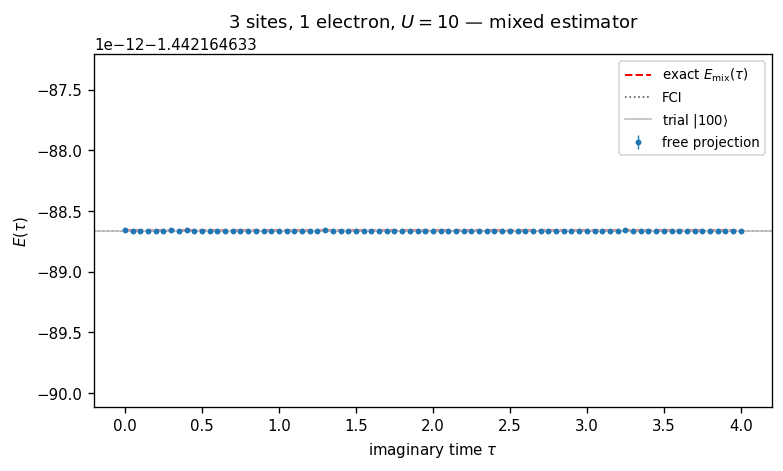

In [11]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(tau_grid, e_exact, "r--", lw=1.2, label=r"exact $E_{\rm mix}(\tau)$")
ax.axhline(e_fci, color="0.35", lw=1.0, ls=":", label="FCI")
ax.axhline(v_T @ h1 @ v_T, color="0.75", lw=1.0, label=r"trial $|100\rangle$")
ax.errorbar(fp.tau, fp.energy, fp.error, fmt="o", ms=2.5, lw=0.8,
            color="C0", label="free projection")

ax.set_xlabel(r"imaginary time $\tau$")
ax.set_ylabel(r"$E(\tau)$")
ax.set_title(r"3 sites, 1 electron, $U=%g$ — mixed estimator" % U)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()

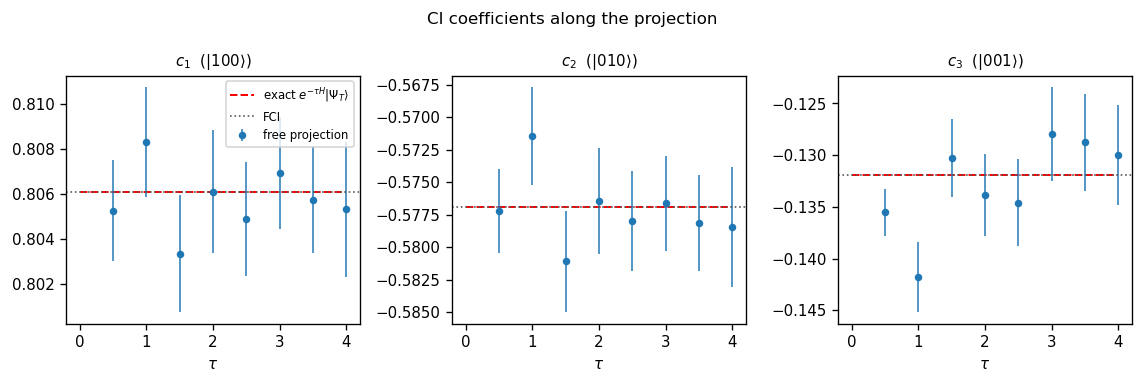

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2), sharex=True)
labels = [r"$c_1$  ($|100\rangle$)", r"$c_2$  ($|010\rangle$)", r"$c_3$  ($|001\rangle$)"]
fp_c    = np.array([fp_wfn[t]["c"] for t in fp_taus])
fp_cerr = np.array([fp_wfn[t]["c_err"] for t in fp_taus])

for k, ax in enumerate(axes):
    ax.plot(tau_grid, c_exact[:, k], "r--", lw=1.2,
            label=r"exact $e^{-\tau H}|\Psi_T\rangle$")
    ax.errorbar(fp_taus, fp_c[:, k], fp_cerr[:, k], fmt="o", ms=3.5, lw=0.9,
                color="C0", label="free projection")
    ax.axhline(c_fci[k], color="0.35", lw=1.0, ls=":", label="FCI")
    ax.set_xlabel(r"$\tau$"); ax.set_title(labels[k], fontsize=9)
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("CI coefficients along the projection", fontsize=10)
fig.tight_layout(); plt.show()

In [13]:
c = hubbard.ci_vectors(sn)  

In [14]:
c = hubbard.ci_vectors(fp.snaps_at(fp.tau[-1])[0]) 

In [15]:
hubbard.angles_of(c[0])

array([ 1.580903, -0.452913])

In [16]:
def cloud(snaps, n_max=40000, seed=0):
    """
    Per-walker angles and signed contribution weight of a set of snapshots.

    The plotted point is the direction of the walker's *contribution*
    coef_w |phi_w> (coef_w = W_w for free projection, W_w/<Psi_T|phi_w> for the
    constrained path), so a walker that enters |Psi> with a negative sign shows up on
    the opposite side of the sphere rather than being silently folded back.
    """
    ang, wt = [], []
    for sn in snaps:
        c = hubbard.ci_vectors(sn)                              # (n_walkers, 3)
        coef = sn.weights / sn.overlaps if sn.importance else sn.weights
        d = coef[:, None] * c
        n = np.linalg.norm(d, axis=1)
        keep = (n > 0) & np.isfinite(n)
        ang.append(hubbard.angles_of(d[keep] / n[keep, None]))
        wt.append(n[keep])
    ang, wt = np.concatenate(ang), np.concatenate(wt)
    # if ang.shape[0] > n_max:
    #     idx = np.random.default_rng(seed).choice(ang.shape[0], n_max, replace=False)
    #     ang, wt = ang[idx], wt[idx]
    return ang[:, 1], ang[:, 0], wt / wt.max()                  # phi, theta, weight


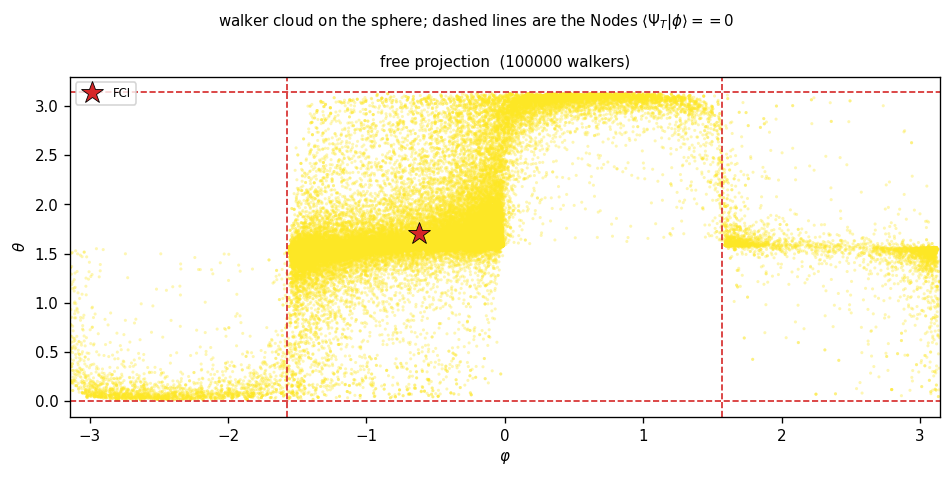

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4), sharex=True, sharey=True)
for ax, (name, snaps) in zip([axes], [("free projection", fp.snaps_at(fp_taus[-1]))]):
    ph_w, th_w, w = cloud(snaps)
    ax.scatter(ph_w, th_w, s=3.0 * w + 0.4, c=w, cmap="viridis",
               alpha=0.35, lw=0, vmin=0, vmax=1)
    for x in (-np.pi / 2, np.pi / 2):
        ax.axvline(x, color="C3", lw=1.0, ls="--")
    for y in (0, np.pi):
        ax.axhline(y, color="C3", lw=1.0, ls="--")
    ax.plot(ph_fci, th_fci, "*", ms=14, color="C3", mec="k", mew=0.5, label="FCI")
    # ax.plot(0.0, np.pi / 2, "s", ms=7, color="w", mec="k", mew=0.9, label=r"trial $|100\rangle$")
    ax.set_xlabel(r"$\varphi$"); ax.set_title("%s  (%d walkers)" % (name, ph_w.size), fontsize=9)
    ax.set_xlim(-np.pi, np.pi); #ax.set_ylim(0, np.pi)
axes.set_ylabel(r"$\theta$")
axes.legend(fontsize=7, loc="upper left")
fig.suptitle(r"walker cloud on the sphere; dashed lines are the Nodes "
             r"$\langle\Psi_T|\phi\rangle==0$", fontsize=9)
fig.tight_layout(); plt.show()

## 5b.  The nodes of the trial, and where the walkers sit

$\langle\Psi_T|\phi\rangle = 0$ is a **great circle** on the walker sphere — the equator
belonging to the trial, tilted so that $|\Psi_T\rangle$ is its pole.  In the notebook's
parametrisation, with the trial at $(\theta_t,\varphi_t)$,

$$
\langle\Psi_T|\phi\rangle
 = \underbrace{\sin\theta_t\cos(\varphi-\varphi_t)}_{a}\,\sin\theta
 + \underbrace{\cos\theta_t}_{b}\,\cos\theta ,
$$

so $a\sin\theta_n + b\cos\theta_n = 0$, i.e.

$$
\boxed{\;\cot\theta_n(\varphi) \;=\; -\tan\theta_t\,\cos(\varphi-\varphi_t)\;}
\qquad \theta_n\in(0,\pi).
$$

One $\theta$ for every $\varphi$: the node is a single-valued curve across the whole
$\varphi$ range, so it does have *both* angles, and it is not a set of straight lines.
Two checks of the formula: at $\varphi=\varphi_t$ it gives $\theta_n=\theta_t+\pi/2 \bmod \pi$
(a quarter turn from the trial along its own meridian), and at $\varphi=\varphi_t\pm\pi/2$ it
gives $\theta_n=\pi/2$ (the node crosses the true equator there).  Its excursion in $\theta$
is $[\arccos\sin\theta_t,\ \pi-\arccos\sin\theta_t]$.

The degenerate case is a trial sitting on the equator, $\cos\theta_t=0$: then $b=0$, the
formula has no solution for generic $\varphi$, and the node collapses to the two meridians
$\varphi=\varphi_t\pm\pi/2$ plus the poles.  That is exactly the old $|100\rangle$ trial, and
it is why the hard-coded vertical/horizontal lines in the scratch plot above looked the way
they did.  With the exact trial they are simply wrong, and the curve below replaces them.

A determinant is a ray, so $|\phi\rangle$ and $-|\phi\rangle$ are the same walker: the whole
picture is symmetric under the antipodal map $(\theta,\varphi)\to(\pi-\theta,\varphi\pm\pi)$,
the trial appears twice, and the node — being a great circle — is mapped onto itself.

In [18]:
th_t, ph_t = hubbard.angles_of(v_T)

def trial_nodes(phi, theta_t=None, phi_t=None):
    """
    theta_n(phi) on the nodal great circle <Psi_T|phi> = 0.

    Solves a sin(theta) + b cos(theta) = 0 with a = sin(tt) cos(phi - pt) and
    b = cos(tt), i.e. cot(theta_n) = -tan(tt) cos(phi - pt), taking the root with
    sin(theta_n) >= 0 so that theta_n lands in (0, pi).  Raises if the trial is on
    the equator, where the node is not a function of phi.
    """
    theta_t = th_t if theta_t is None else theta_t
    phi_t   = ph_t if phi_t   is None else phi_t
    a = np.sin(theta_t) * np.cos(np.asarray(phi, dtype=float) - phi_t)
    b = np.cos(theta_t)
    if abs(b) < 1e-13:
        raise ValueError("trial on the equator: the node is phi = phi_t +/- pi/2, "
                         "not a single-valued function of phi")
    return np.arctan2(abs(b), -a * np.sign(b))

phi_n = np.linspace(-np.pi, np.pi, 1441)
th_n  = trial_nodes(phi_n)

print("trial   c = (%+.6f, %+.6f, %+.6f)" % tuple(v_T))
print("        theta_t = %+.8f   phi_t = %+.8f" % (th_t, ph_t))
print("\nnode    cot(theta_n) = -tan(theta_t) cos(phi - phi_t)")
print("  max |<Psi_T|node>|                = %.2e" % np.abs(from_angles(th_n, phi_n) @ v_T).max())
print("  theta_n range                     = [%.8f, %.8f]" % (th_n.min(), th_n.max()))
print("  predicted [arccos sin tt, pi - .] = [%.8f, %.8f]"
      % (np.arccos(abs(np.sin(th_t))), np.pi - np.arccos(abs(np.sin(th_t)))))
print("  theta_n(phi_t)        = %.8f   (theta_t + pi/2 mod pi = %.8f)"
      % (trial_nodes(ph_t), (th_t + np.pi / 2) % np.pi))
print("  theta_n(phi_t + pi/2) = %.8f   (pi/2 = %.8f)"
      % (trial_nodes(ph_t + np.pi / 2), np.pi / 2))

# Independent check: the same circle built from an orthonormal basis of the plane
# perpendicular to Psi_T, with no reference to the angle parametrisation at all.
e1 = np.cross(v_T, [0.0, 0.0, 1.0]); e1 /= np.linalg.norm(e1)
e2 = np.cross(v_T, e1)
s  = np.linspace(0.0, 2 * np.pi, 1441)
gc = np.cos(s)[:, None] * e1 + np.sin(s)[:, None] * e2
ang_gc = hubbard.angles_of(gc)
print("\n  max |<Psi_T|great circle>|        = %.2e" % np.abs(gc @ v_T).max())
print("  max |theta_gc - theta_n(phi_gc)|  = %.2e"
      % np.abs(ang_gc[:, 0] - trial_nodes(ang_gc[:, 1])).max())

trial   c = (+0.806081, -0.576922, -0.131889)
        theta_t = +1.70307094   phi_t = -0.62119317

node    cot(theta_n) = -tan(theta_t) cos(phi - phi_t)
  max |<Psi_T|node>|                = 2.50e-16
  theta_n range                     = [0.13227478, 3.00931787]
  predicted [arccos sin tt, pi - .] = [0.13227461, 3.00931804]
  theta_n(phi_t)        = 0.13227461   (theta_t + pi/2 mod pi = 0.13227461)
  theta_n(phi_t + pi/2) = 1.57079633   (pi/2 = 1.57079633)

  max |<Psi_T|great circle>|        = 1.67e-16
  max |theta_gc - theta_n(phi_gc)|  = 3.11e-15


### The walker population, and its weight either side of the node

Free projection carries no importance sampling, so the ensemble *is* the wavefunction,
$|\Psi\rangle=\sum_w W_w|\phi_w\rangle$ with $W_w>0$; the sign lives in the walker's own
orientation.  Each walker is therefore plotted at the direction of its signed contribution
$W_w|\phi_w\rangle$, and $\langle\Psi_T|\phi_w\rangle$ says which side of the node it fell on.
The weight sitting on the wrong side is the free-projection sign problem, measured directly.

In [19]:
TAU_PLOT = fp_taus[-1]

def walker_cloud(snaps):
    """
    (phi, theta, weight, overlap) for every walker in a set of snapshots.

    The direction returned is that of the walker's signed contribution
    coef_w |phi_w>  (coef_w = W_w for free projection, W_w / <Psi_T|phi_w> when the
    snapshot is importance sampled), so a walker entering |Psi> with a negative sign
    shows up on the far side of the sphere rather than being folded back.  `overlap`
    is <Psi_T|phi_w> evaluated on that direction: its sign is the side of the node.
    """
    ang, wt = [], []
    for sn in snaps:
        c    = hubbard.ci_vectors(sn)                       # (n_walkers, 3)
        coef = sn.weights / sn.overlaps if sn.importance else sn.weights
        d    = coef[:, None] * c
        n    = np.linalg.norm(d, axis=1)
        keep = (n > 0) & np.isfinite(n)
        ang.append(hubbard.angles_of(d[keep] / n[keep, None]))
        wt.append(n[keep])
    ang, wt = np.concatenate(ang), np.concatenate(wt)
    th, ph  = ang[:, 0], ang[:, 1]
    return ph, th, wt, from_angles(th, ph) @ v_T

ph_w, th_w, w_w, ovl_w = walker_cloud(fp.snaps_at(TAU_PLOT))
w_w = w_w / w_w.sum()                                   # a probability weight
pos = ovl_w > 0

print("tau = %.2f : %d walkers from %d trajectories" % (TAU_PLOT, ph_w.size, fp.n_runs))
print("  weight with <Psi_T|phi> > 0     : %6.2f %%" % (100 * w_w[pos].sum()))
print("  weight with <Psi_T|phi> < 0     : %6.2f %%" % (100 * w_w[~pos].sum()))
print("  sum_w W |<Psi_T|phi_w>|         : %+.6f" % np.sum(w_w * np.abs(ovl_w)))
print("  sum_w W  <Psi_T|phi_w>          : %+.6f   <- the signal that survives"
      % np.sum(w_w * ovl_w))
print("  ratio (average sign)            : %+.6f"
      % (np.sum(w_w * ovl_w) / np.sum(w_w * np.abs(ovl_w))))

tau = 4.00 : 100000 walkers from 100 trajectories
  weight with <Psi_T|phi> > 0     :  94.04 %
  weight with <Psi_T|phi> < 0     :   5.96 %
  sum_w W |<Psi_T|phi_w>|         : +0.752991
  sum_w W  <Psi_T|phi_w>          : +0.689492   <- the signal that survives
  ratio (average sign)            : +0.915671


normalisation checks:  int rho(phi) dphi = 1.000000   int rho(theta) dtheta = 1.000000


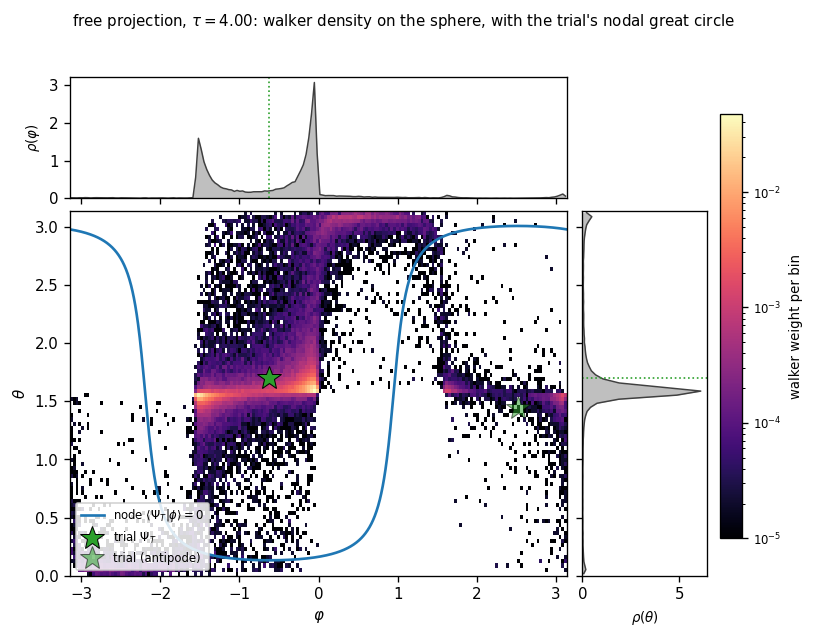

In [20]:
# One weighted 2-D histogram of the population on the sphere.  The two marginals are
# literally its row and column sums, i.e. the density integrated over the other angle.
NB_P, NB_T = 180, 90
ep = np.linspace(-np.pi, np.pi, NB_P + 1)
et = np.linspace(0.0,    np.pi, NB_T + 1)
dp, dt_ = ep[1] - ep[0], et[1] - et[0]
ctr_p, ctr_t = 0.5 * (ep[1:] + ep[:-1]), 0.5 * (et[1:] + et[:-1])

H,  _, _ = np.histogram2d(ph_w,       th_w,       bins=[ep, et], weights=w_w)
Hp, _, _ = np.histogram2d(ph_w[pos],  th_w[pos],  bins=[ep, et], weights=w_w[pos])
Hm, _, _ = np.histogram2d(ph_w[~pos], th_w[~pos], bins=[ep, et], weights=w_w[~pos])

rho_phi,   rho_theta   = H.sum(1) / dp,  H.sum(0) / dt_
rho_phi_p, rho_theta_p = Hp.sum(1) / dp, Hp.sum(0) / dt_
rho_phi_m, rho_theta_m = Hm.sum(1) / dp, Hm.sum(0) / dt_
print("normalisation checks:  int rho(phi) dphi = %.6f   int rho(theta) dtheta = %.6f"
      % (rho_phi.sum() * dp, rho_theta.sum() * dt_))

fig = plt.figure(figsize=(7.4, 5.4))
gs  = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 3),
                       wspace=0.05, hspace=0.05)
ax  = fig.add_subplot(gs[1, 0])
axp = fig.add_subplot(gs[0, 0], sharex=ax)
axt = fig.add_subplot(gs[1, 1], sharey=ax)

# log colour scale: the population spans several decades, and the sparse weight that
# has crossed the node is the interesting part
pcm = ax.pcolormesh(ep, et, np.ma.masked_equal(H, 0).T, cmap="magma", shading="auto",
                    norm=matplotlib.colors.LogNorm(vmin=H[H > 0].min(), vmax=H.max()))
ax.plot(phi_n, th_n, "-", color="C0", lw=1.6, label=r"node $\langle\Psi_T|\phi\rangle=0$")
ax.plot(ph_t, th_t, "*", ms=15, color="C2", mec="k", mew=0.6, label=r"trial $\Psi_T$")
ax.plot(ph_t - np.sign(ph_t) * np.pi, np.pi - th_t, "*", ms=15, color="C2",
        mec="k", mew=0.6, alpha=0.55, label=r"trial (antipode)")
ax.set_xlabel(r"$\varphi$"); ax.set_ylabel(r"$\theta$")
ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, np.pi)
ax.legend(fontsize=7, loc="lower left", framealpha=0.85)

axp.fill_between(ctr_p, rho_phi, color="0.75", lw=0)
axp.plot(ctr_p, rho_phi, color="0.25", lw=0.9)
axp.axvline(ph_t, color="C2", lw=1.0, ls=":")
axp.set_ylabel(r"$\rho(\varphi)$", fontsize=8); axp.tick_params(labelbottom=False)
axp.set_ylim(bottom=0)

axt.fill_betweenx(ctr_t, rho_theta, color="0.75", lw=0)
axt.plot(rho_theta, ctr_t, color="0.25", lw=0.9)
axt.axhline(th_t, color="C2", lw=1.0, ls=":")
axt.set_xlabel(r"$\rho(\theta)$", fontsize=8); axt.tick_params(labelleft=False)
axt.set_xlim(left=0)

cb = fig.colorbar(pcm, ax=[axp, ax, axt], location="right", fraction=0.055,
                  pad=0.02, shrink=0.85)
cb.set_label("walker weight per bin", fontsize=8)
cb.ax.tick_params(labelsize=7)
fig.suptitle(r"free projection, $\tau=%.2f$: walker density on the sphere, "
             r"with the trial's nodal great circle" % TAU_PLOT, fontsize=9)
plt.show()

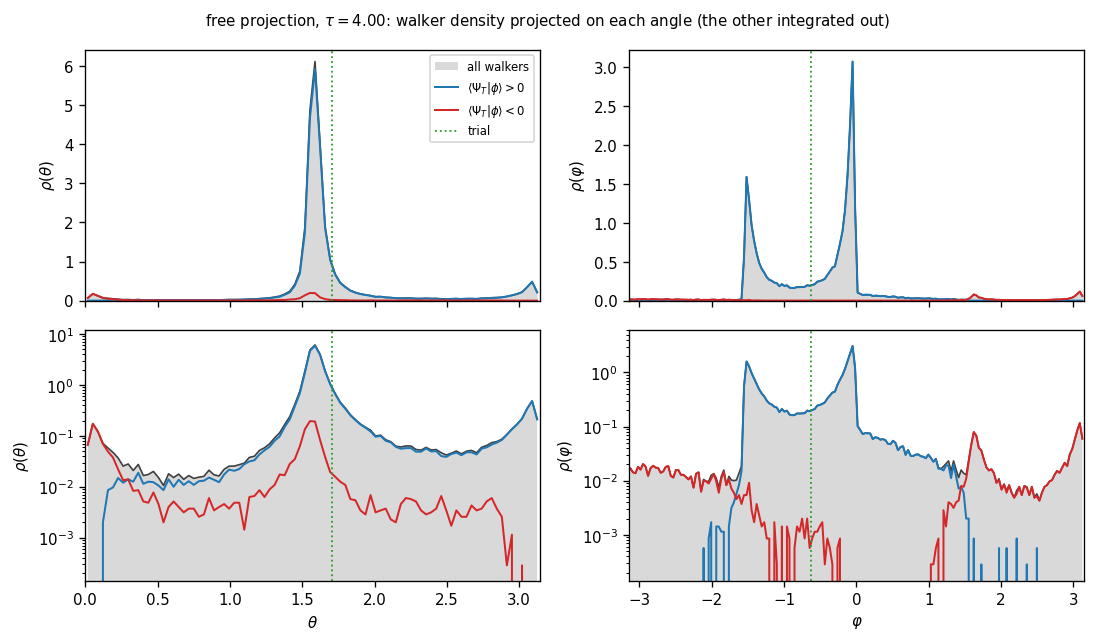

In [21]:
# The same two marginals on their own, split by which side of the node the weight sits.
# Top row linear (the bulk), bottom row logarithmic (the weight that crossed the node).
fig, axes = plt.subplots(2, 2, figsize=(9.2, 5.4), sharex="col")

for col, (ctr, tot, p, m, lab, mark, xlim) in enumerate((
        (ctr_t, rho_theta, rho_theta_p, rho_theta_m, r"\theta",  th_t, (0, np.pi)),
        (ctr_p, rho_phi,   rho_phi_p,   rho_phi_m,   r"\varphi", ph_t, (-np.pi, np.pi)))):
    for row in (0, 1):
        ax = axes[row, col]
        ax.fill_between(ctr, tot, color="0.85", lw=0, label="all walkers")
        ax.plot(ctr, tot, color="0.25", lw=1.0)
        ax.plot(ctr, p, color="C0", lw=1.2, label=r"$\langle\Psi_T|\phi\rangle>0$")
        ax.plot(ctr, m, color="C3", lw=1.2, label=r"$\langle\Psi_T|\phi\rangle<0$")
        ax.axvline(mark, color="C2", lw=1.1, ls=":", label="trial")
        ax.set_ylabel(r"$\rho(%s)$" % lab)
        ax.set_xlim(*xlim)
        if row == 0:
            ax.set_ylim(bottom=0)
        else:
            ax.set_yscale("log")
            lo = min(x[x > 0].min() for x in (p, m) if (x > 0).any())
            ax.set_ylim(0.5 * lo, 2 * tot.max())
            ax.set_xlabel("$%s$" % lab)
axes[0, 0].legend(fontsize=7)
fig.suptitle(r"free projection, $\tau=%.2f$: walker density projected on each angle "
             r"(the other integrated out)" % TAU_PLOT, fontsize=9)
fig.tight_layout(); plt.show()

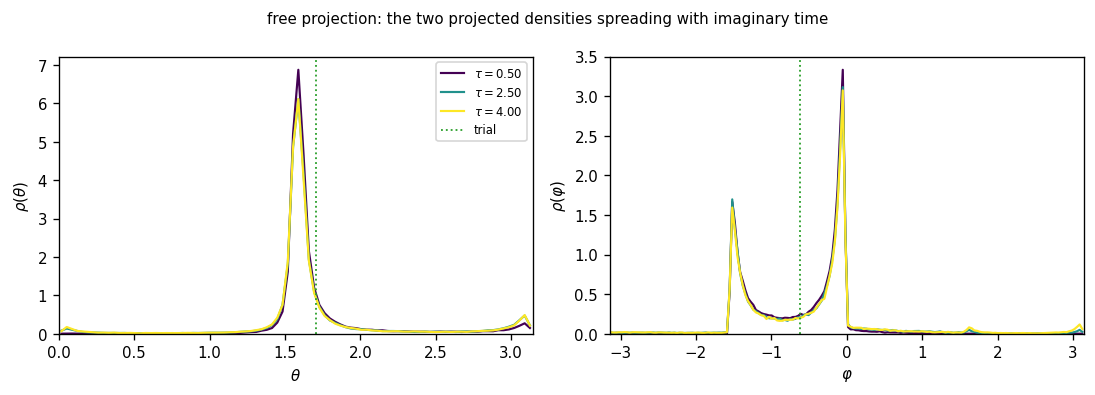

In [22]:
# How the two projections build up along the projection time.
taus_show = [fp_taus[0], fp_taus[len(fp_taus) // 2], fp_taus[-1]]
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3))

for k, tau in enumerate(taus_show):
    p_, t_, wt_, _ = walker_cloud(fp.snaps_at(tau))
    wt_ = wt_ / wt_.sum()
    ht, _ = np.histogram(t_, bins=et, weights=wt_)
    hp, _ = np.histogram(p_, bins=ep, weights=wt_)
    col = plt.cm.viridis(k / max(1, len(taus_show) - 1))
    axes[0].plot(ctr_t, ht / dt_, color=col, lw=1.3, label=r"$\tau=%.2f$" % tau)
    axes[1].plot(ctr_p, hp / dp,  color=col, lw=1.3, label=r"$\tau=%.2f$" % tau)

for ax, lab, mark in ((axes[0], r"\theta", th_t), (axes[1], r"\varphi", ph_t)):
    ax.axvline(mark, color="C2", lw=1.1, ls=":", label="trial")
    ax.set_xlabel("$%s$" % lab); ax.set_ylabel(r"$\rho(%s)$" % lab)
    ax.set_ylim(bottom=0)
axes[0].set_xlim(0, np.pi); axes[1].set_xlim(-np.pi, np.pi)
axes[0].legend(fontsize=7)
fig.suptitle("free projection: the two projected densities spreading with imaginary time",
             fontsize=9)
fig.tight_layout(); plt.show()

In [23]:
# Where does the density actually sit, and why is it not on the trial?
from itertools import product
import scipy.linalg as sla

print("marginal peaks :  theta = %.4f   (pi/2 = %.4f, the c3 = 0 plane)"
      % (ctr_t[np.argmax(rho_theta)], np.pi / 2))
print("                  phi   = %.4f   (0 = the c2 = 0 plane)" % ctr_p[np.argmax(rho_phi)])
print("trial          :  theta = %.4f   phi = %.4f" % (th_t, ph_t))

sgn = np.sign(from_angles(th_w, ph_w))
gs  = np.sign(v_T)
print("\nwalker weight by octant (signs of c1, c2, c3):")
for s in product((1.0, -1.0), repeat=3):
    m = np.all(sgn == np.array(s), axis=1)
    if w_w[m].sum() > 1e-4:
        print("   (%+d,%+d,%+d) : %6.2f %%%s"
              % (int(s[0]), int(s[1]), int(s[2]), 100 * w_w[m].sum(),
                 "   <- the ground state's octant" if tuple(s) == tuple(gs) else ""))

# Why: with the spin (Hirsch) decomposition the field propagator is a POSITIVE
# DIAGONAL rescaling, so it cannot flip the sign of any component -- a walker's
# octant is invariant under it, and only the one-body factor can carry a walker
# across a coordinate plane (and hence across the node).
Lg = np.asarray(hubbard.spin_chol(NSITE, U)[0])
Mx = sla.expm(1j * np.sqrt(DT_FP) * np.einsum("g,gij->ij", np.array([0.7, -1.2, 0.3]), Lg))
Kx = sla.expm(-0.5 * DT_FP * h1)
n_steps = int(round(fp.tau[-1] / DT_FP))
print("\nfield propagator exp(i sqrt(dt) x.L):  diagonal %s | real %s | positive %s"
      % (np.allclose(Mx, np.diag(np.diag(Mx))), np.abs(Mx.imag).max() < 1e-15,
         bool((np.diag(Mx).real > 0).all())))
print("  it is exp(sqrt(U dt) x_g) with sqrt(U dt) = %.3f per step; over the %d steps"
      % (np.sqrt(U * DT_FP), n_steps))
print("  of this run the log amplitudes random-walk by sigma = %.1f, which collapses"
      % (np.sqrt(U * DT_FP) * np.sqrt(n_steps)))
print("  components and piles the density onto the coordinate planes.")
print("one-body half step exp(-dt h1/2):  max off-diagonal = %.1e -- the only thing"
      % np.abs(Kx - np.diag(np.diag(Kx))).max())
print("  that can move a walker between octants, or across the node.")

marginal peaks :  theta = 1.5882   (pi/2 = 1.5708, the c3 = 0 plane)
                  phi   = -0.0524   (0 = the c2 = 0 plane)
trial          :  theta = 1.7031   phi = -0.6212

walker weight by octant (signs of c1, c2, c3):
   (+1,+1,-1) :   6.17 %
   (+1,-1,+1) :  30.24 %
   (+1,-1,-1) :  57.93 %   <- the ground state's octant
   (-1,+1,+1) :   2.05 %
   (-1,+1,-1) :   1.49 %
   (-1,-1,+1) :   2.13 %

field propagator exp(i sqrt(dt) x.L):  diagonal True | real True | positive True
  it is exp(sqrt(U dt) x_g) with sqrt(U dt) = 0.100 per step; over the 4000 steps
  of this run the log amplitudes random-walk by sigma = 6.3, which collapses
  components and piles the density onto the coordinate planes.
one-body half step exp(-dt h1/2):  max off-diagonal = 4.8e-04 -- the only thing
  that can move a walker between octants, or across the node.


### Reading the three plots

**The walker density is not centred on the trial, and it does not converge to it.**  The
marginals peak on the *coordinate planes* — $\theta=\pi/2$ ($c_3=0$) and $\varphi=0$,
$-\pi/2$ ($c_2=0$, $c_1=0$) — with the trial sitting on the shoulder of the ridge, and the
last plot shows the two projections are already stationary by $\tau=0.5$ and do not move
afterwards.

That is the spin (Hirsch) decomposition at work.  Its field propagator is
$\exp(i\sqrt{\delta\tau}\,x_g L_g) = \exp(\sqrt{U\delta\tau}\,x_g)|g\rangle\langle g|$ — a
*positive diagonal rescaling*.  It cannot flip the sign of any component, so a walker's
octant is invariant under it, and at $\sqrt{U\delta\tau}=0.1$ per step over 4000 steps the
log amplitudes random-walk by $\sigma\approx6$: individual components are driven to zero and
the population collapses onto the planes bounding the ground state's octant $(+,-,-)$.  Only
the one-body factor, whose off-diagonal elements are $\sim5\times10^{-4}$ per half step,
can carry a walker across a coordinate plane — or across the node.

So the ground state is **not** recovered from where the walkers are; it is recovered from
the *weighted* average over them, which is exactly what §5 found
($c$ correct to $\sim10^{-3}$).  The density and the answer are different objects.

**The node splits the population 94 / 6.**  At $\tau=4$, $94.0\,\%$ of the walker weight has
$\langle\Psi_T|\phi\rangle>0$ and $6.0\,\%$ has crossed to the far side, giving an average
sign of $0.916$.  That minority is the free-projection sign problem for this system, and the
log-scale panels show where it lives: spread thinly over the whole sphere, concentrated near
the same coordinate planes rather than hugging the node.  A constrained-path run would
delete precisely that $6\,\%$ — which is the comparison to run next.

## 6.  Constrained-path AFQMC

Importance sampling with the same trial, and walkers killed the moment
$\langle\Psi_T|\phi_w\rangle$ would change sign.  The mixed distribution is sampled, so
reconstructing $|\Psi\rangle$ divides the trial overlap back out,
$|\Psi\rangle=\sum_w (W_w/\langle\Psi_T|\phi_w\rangle)|\phi_w\rangle$ — `hubbard.reconstruct`
picks that up from the snapshot automatically.

**One walk, not many.**  Unlike free projection, constrained path has a steady state:
importance sampling keeps the weights alive, so the walk is equilibrated once and then
sampled block after block, exactly as `afqmc/scripts/run_afqmc.py` does.  Restarting it
$N$ times would pay the equilibration cost $N$ times over and buy nothing.  The price is
that consecutive blocks are correlated, so the energy error bar comes from a blocking
analysis of the single series (`sampling.blocking`, via `QMCResult.plateau`), and the
snapshots are labelled by which contiguous **bin** of the walk they came from so that
`hubbard.wavefunction` jackknifes over bins rather than over neighbouring, correlated
snapshots.

The constraint here has a completely explicit geometry:
$\langle\Psi_T|\phi\rangle=\sin\theta\cos\varphi$ for the $|100\rangle$ trial, so such a
walker can never leave the wedge $|\varphi|<\pi/2$, whereas free projection roams the whole
sphere.

In [24]:
cp = hubbard.run_constrained(
        qmc, method="cp", dt=0.001, n_walkers=2000, n_prop_steps=50,
        n_blocks=400, eql_time=10.0, seed=0, n_exp_terms=10,
        n_bins=10, snap_every=4, verbose=1)


Constrained path | 2000 walkers | equilibrating 200 blocks to tau = 10.00
  eql   40/200  tau =   2.00  E(block) =   -1.44216     3.4 s
  eql   80/200  tau =   4.00  E(block) =   -1.44216     3.9 s
  eql  120/200  tau =   6.00  E(block) =   -1.44216     4.3 s
  eql  160/200  tau =   8.00  E(block) =   -1.44216     4.7 s
  eql  200/200  tau =  10.00  E(block) =   -1.44216     5.1 s

Constrained path | sampling 400 blocks from the same walk
  block     tau    E(block)         <E>        err  walltime
      4   10.20    -1.44216    -1.44216         --       5.1
      8   10.40    -1.44216    -1.44216         --       5.2
     12   10.60    -1.44216    -1.44216         --       5.2
     16   10.80    -1.44216    -1.44216         --       5.3
     20   11.00    -1.44216    -1.44216         --       5.3
     24   11.20    -1.44216    -1.44216    0.00000       5.4
     28   11.40    -1.44216    -1.44216    0.00000       5.4
     32   11.60    -1.44216    -1.44216    0.00000       5.4
     36

In [25]:
e_cp, e_cp_err = cp.plateau()
r_cp = hubbard.wavefunction(cp.snaps, qmc.ci_hamiltonian, v_T)

print("constrained path: %d blocks sampled from one walk after tau_eq = %.1f"
      % (cp.block_energies.shape[1], cp.tau_eq))
print("  c     = (%+.6f, %+.6f, %+.6f)" % tuple(r_cp["c"]))
print("  +/-   = ( %.6f,  %.6f,  %.6f)   (jackknife over %d bins of the walk)"
      % (*r_cp["c_err"], r_cp["n_groups"]))
print("  theta = %+.6f +/- %.6f    (FCI %+.6f)" % (r_cp["theta"], r_cp["theta_err"], th_fci))
print("  phi   = %+.6f +/- %.6f    (FCI %+.6f)" % (r_cp["phi"], r_cp["phi_err"], ph_fci))
print("  E_var = %+.6f    E_mix = %+.5f +/- %.5f    (FCI %+.6f)"
      % (r_cp["e_var"], e_cp, e_cp_err, e_fci))

constrained path: 400 blocks sampled from one walk after tau_eq = 10.0
  c     = (+0.804092, -0.576178, -0.146476)
  +/-   = ( 0.001776,  0.002937,  0.004413)   (jackknife over 10 bins of the walk)
  theta = +1.717801 +/- 0.004461    (FCI +1.703071)
  phi   = -0.621753 +/- 0.003406    (FCI -0.621193)
  E_var = -1.441829    E_mix = -1.44216 +/- 0.00000    (FCI -1.442165)


## 7.  The three answers side by side

In [26]:
rows = [("FCI",               c_fci,      None,             e_fci,        None),
        ("free projection",   r_fp["c"],  r_fp["c_err"],    r_fp["e_var"], fp.energy[-1]),
        ("constrained path",  r_cp["c"],  r_cp["c_err"],    r_cp["e_var"], e_cp)]

print("CI coefficients in the basis {|100>, |010>, |001>}")
print("-" * 92)
print("%-18s %11s %11s %11s %10s %10s %11s" % ("", "c1", "c2", "c3", "theta", "phi", "E_var"))
print("-" * 92)
for name, c, cerr, evar, emix in rows:
    th, ph = hubbard.angles_of(c)
    print("%-18s %+11.6f %+11.6f %+11.6f %10.6f %10.6f %+11.6f"
          % (name, c[0], c[1], c[2], th, ph, evar))
    if cerr is not None:
        print("%-18s %11s %11s %11s"
              % ("  +/-", "%.6f" % cerr[0], "%.6f" % cerr[1], "%.6f" % cerr[2]))
print("-" * 92)
print("deviation from FCI, |c - c_FCI|:")
for name, c, cerr, evar, emix in rows[1:]:
    print("  %-18s %.2e   (energy error %+.2e)" % (name, np.linalg.norm(c - c_fci), evar - e_fci))

CI coefficients in the basis {|100>, |010>, |001>}
--------------------------------------------------------------------------------------------
                            c1          c2          c3      theta        phi       E_var
--------------------------------------------------------------------------------------------
FCI                  +0.806081   -0.576922   -0.131889   1.703071  -0.621193   -1.442165
free projection      +0.805306   -0.578431   -0.129995   1.701160  -0.622886   -1.442158
  +/-                 0.003002    0.004622    0.004846
constrained path     +0.804092   -0.576178   -0.146476   1.717801  -0.621753   -1.441829
  +/-                 0.001776    0.002937    0.004413
--------------------------------------------------------------------------------------------
deviation from FCI, |c - c_FCI|:
  free projection    2.54e-03   (energy error +7.09e-06)
  constrained path   1.47e-02   (energy error +3.36e-04)


## 8.  Plots

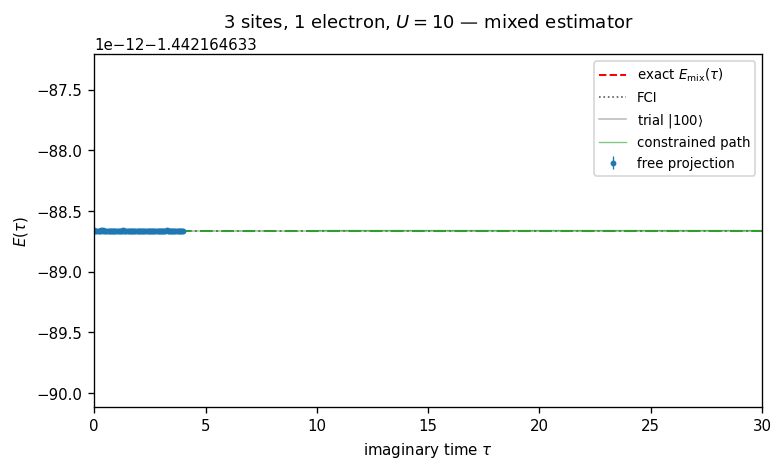

In [27]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(tau_grid, e_exact, "r--", lw=1.2, label=r"exact $E_{\rm mix}(\tau)$")
ax.axhline(e_fci, color="0.35", lw=1.0, ls=":", label="FCI")
ax.axhline(v_T @ h1 @ v_T, color="0.75", lw=1.0, label=r"trial $|100\rangle$")
ax.errorbar(fp.tau, fp.energy, fp.error, fmt="o", ms=2.5, lw=0.8,
            color="C0", label="free projection")
ax.fill_between(cp.tau, e_cp - e_cp_err, e_cp + e_cp_err,
                color="C2", alpha=0.35, lw=0)
ax.plot(cp.tau, cp.energy, "-", lw=0.8, color="C2", alpha=0.6, label="constrained path")
ax.axhline(e_cp, color="C2", lw=1.2, ls="-.")
ax.set_xlabel(r"imaginary time $\tau$")
ax.set_ylabel(r"$E(\tau)$")
ax.set_xlim(0, max(fp.tau[-1], cp.tau[-1]))
ax.set_title(r"3 sites, 1 electron, $U=%g$ — mixed estimator" % U)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()

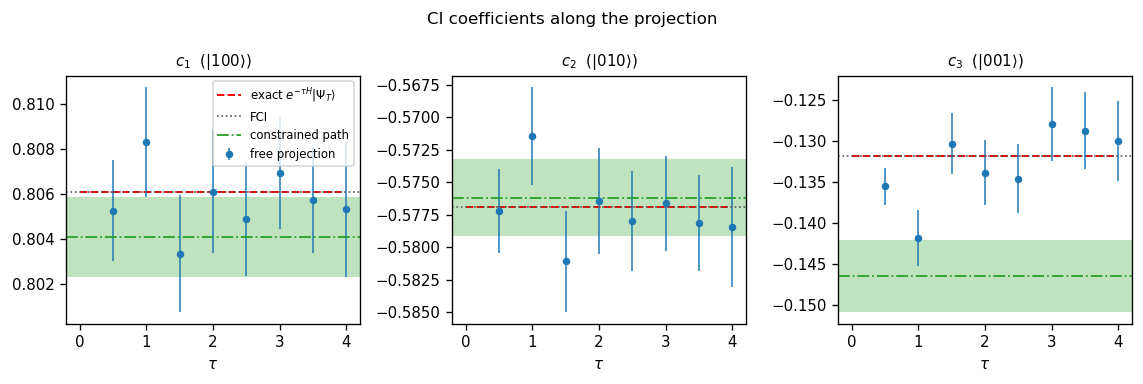

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2), sharex=True)
labels = [r"$c_1$  ($|100\rangle$)", r"$c_2$  ($|010\rangle$)", r"$c_3$  ($|001\rangle$)"]
fp_c    = np.array([fp_wfn[t]["c"] for t in fp_taus])
fp_cerr = np.array([fp_wfn[t]["c_err"] for t in fp_taus])

for k, ax in enumerate(axes):
    ax.plot(tau_grid, c_exact[:, k], "r--", lw=1.2,
            label=r"exact $e^{-\tau H}|\Psi_T\rangle$")
    ax.errorbar(fp_taus, fp_c[:, k], fp_cerr[:, k], fmt="o", ms=3.5, lw=0.9,
                color="C0", label="free projection")
    ax.axhline(c_fci[k], color="0.35", lw=1.0, ls=":", label="FCI")
    ax.axhspan(r_cp["c"][k] - r_cp["c_err"][k], r_cp["c"][k] + r_cp["c_err"][k],
               color="C2", alpha=0.30, lw=0)
    ax.axhline(r_cp["c"][k], color="C2", lw=1.1, ls="-.", label="constrained path")
    ax.set_xlabel(r"$\tau$"); ax.set_title(labels[k], fontsize=9)
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("CI coefficients along the projection", fontsize=10)
fig.tight_layout(); plt.show()

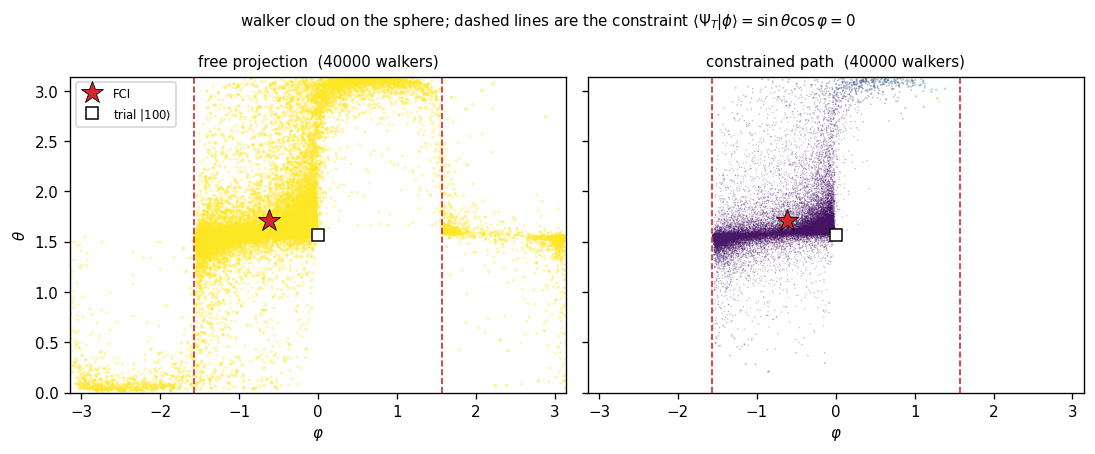

In [29]:
def cloud(snaps, n_max=40000, seed=0):
    """
    Per-walker angles and signed contribution weight of a set of snapshots.

    The plotted point is the direction of the walker's *contribution*
    coef_w |phi_w> (coef_w = W_w for free projection, W_w/<Psi_T|phi_w> for the
    constrained path), so a walker that enters |Psi> with a negative sign shows up on
    the opposite side of the sphere rather than being silently folded back.
    """
    ang, wt = [], []
    for sn in snaps:
        c = hubbard.ci_vectors(sn)                              # (n_walkers, 3)
        coef = sn.weights / sn.overlaps if sn.importance else sn.weights
        d = coef[:, None] * c
        n = np.linalg.norm(d, axis=1)
        keep = (n > 0) & np.isfinite(n)
        ang.append(hubbard.angles_of(d[keep] / n[keep, None]))
        wt.append(n[keep])
    ang, wt = np.concatenate(ang), np.concatenate(wt)
    if ang.shape[0] > n_max:
        idx = np.random.default_rng(seed).choice(ang.shape[0], n_max, replace=False)
        ang, wt = ang[idx], wt[idx]
    return ang[:, 1], ang[:, 0], wt / wt.max()                  # phi, theta, weight

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), sharex=True, sharey=True)
for ax, (name, snaps) in zip(axes, [("free projection", fp.snaps_at(fp_taus[-1])),
                                    ("constrained path", cp.snaps)]):
    ph_w, th_w, w = cloud(snaps)
    ax.scatter(ph_w, th_w, s=3.0 * w + 0.4, c=w, cmap="viridis",
               alpha=0.35, lw=0, vmin=0, vmax=1)
    for x in (-np.pi / 2, np.pi / 2):
        ax.axvline(x, color="C3", lw=1.0, ls="--")
    ax.plot(ph_fci, th_fci, "*", ms=14, color="C3", mec="k", mew=0.5, label="FCI")
    ax.plot(0.0, np.pi / 2, "s", ms=7, color="w", mec="k", mew=0.9, label=r"trial $|100\rangle$")
    ax.set_xlabel(r"$\varphi$"); ax.set_title("%s  (%d walkers)" % (name, ph_w.size), fontsize=9)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, np.pi)
axes[0].set_ylabel(r"$\theta$")
axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle(r"walker cloud on the sphere; dashed lines are the constraint "
             r"$\langle\Psi_T|\phi\rangle=\sin\theta\cos\varphi=0$", fontsize=9)
fig.tight_layout(); plt.show()

## 9.  Summary

* **FCI** — the CI coefficients are the lowest eigenvector of $h_1$; $U$ cancels for a
  single electron.
* **Free projection** — reproduces them within the error bars, even though every walker is
  being driven by a $U=10$ auxiliary field.  The reconstructed $(\theta,\varphi)$ track the
  deterministic $e^{-\tau H}|\Psi_T\rangle$ curve the whole way.  Its *block energy* is the
  one quantity that is slightly biased, by the local-energy clamp discussed in §5.
* **Constrained path** — biased towards the trial, by construction: with
  $|\Psi_T\rangle=|100\rangle$ no walker may leave $|\varphi|<\pi/2$, so weight that the
  exact state wants on $|010\rangle$ (which carries a negative coefficient) is systematically
  cut.  $c_2$ comes out too small in magnitude and $c_1$ too large.